# Clase 04 - Analisis de Datos

---

## Librerias

---

Las librerias a utilizar seran:

In [8]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import re

The only new libraries are:

- yfinance: According to its [documentation](https://ranaroussi.github.io/yfinance/reference/index.html): "The yfinance package provides easy access to Yahoo! Finance’s API to retrieve market data. It includes classes and functions for downloading historical market data, accessing ticker information, managing cache, and more."
- matplotlib: Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. We use two modules within the matplotlib library: (1) The [.pyplot](https://matplotlib.org/stable/api/pyplot_summary.html) module, which introduces plotting capabilities; and (2) the [.dates](https://matplotlib.org/stable/api/dates_api.html) module, which provides sophisticated date plotting capabilities, standing on the shoulders of python datetime.

## Funciones

---

#### Funcion sanitize_col

We define a function to clean/sanitize the column index of our dataframe. This function does the following:

1. It makes the name of the columns all uppercase and replaces whitespaces with underscores.
2. Erases any non uppercase letter or symbol different to an underscore.
3. Subsitutes the first ocurrance of 1 or more contiguous "_" with just one underscore, and removes leading and trailing underscores.

We will loop through this function wich each value in the columns index later on.


In [9]:
def sanitize_col(name: str) -> str:    # By using the "-> str" we specify that output of this function must be an object of type string
    name = name.upper().replace(" ", "_")    # This makes name all uppercase and replaces whitespaces with "_"
    name = re.sub(r"[^A-Z_]", "", name)    # This regex pattern will match any single character that is a lowercase letter, a digit, a space, a symbol (like !, @, #, etc.),
                                           # or any other non-uppercase-letter, non-underscore character.
    name = re.sub(r"_+", "_", name).strip("_")    # Substitute the first ocurrance of 1 or more "_" with just one "_" and remove leading and trailing underscores
    return name

## Using yfinance to dowload stock data

---

Now, we use the yfinance library to download the historic data of the price of the following stocks: 

- "AAPL"
- "MSFT"
- "AMZN"
- "GOOGL"
- "META"
- "NVDA"
- "TSLA"
- "JPM"
- "JNJ"
- "XOM"

We'll use the yfinance function [`yf.download`](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html#yfinance.download) to download yahoo tickers data. This function has several parameters, the most important ones being:

- tickers: str or list of tickers to download
- start: download start date string (YYYY-MM-DD)
- end: download end date string (YYYY-MM-DD)
- auto_adjust: Adjust all OHLC (Open, High, Low, and Close) automatically? The default is True. - THIS PARAMETER HIDES IMPORTANT INSIGHTS.

In [10]:
tks = ["AAPL", "MSFT", "AMZN", "GOOGL", "META", "NVDA", "TSLA", "JPM", "JNJ", "XOM"]

inicio = "2021-01-01"
final = "2025-12-31"

data = yf.download(tickers=tks, start=inicio, end=final, auto_adjust=False, progress=True, threads=True)

[*********************100%***********************]  10 of 10 completed


### Understanging how adjusted close prices work

When a company pays dividens to stock holders or performs a stock split (incresing the number of shares while reducing stock price), the price of the stock naturally adjusts in the market (pues pagar dividendos aumenta el capital y disminuye los activos de la empresa). But for the historical analysis of the price of the stock, we need said prices to be all adjusted across the time series for the data to be comparable. 

The data provider (Yahoo finance) internally adjusts all prices (Open, High, Low and Close) for Corporate Stock Actions like divends, splits and reverse splits. When downloading the historic data of a ticker using .download, we need then to specify if we want yfinance to automatically adjust all prices (Open, High, Low and Close) instead of returning a separate column of adjusted prices. 

By default, it used to be that it would not automatically adjust prices and give an extra column with the adjusted data. But now by default it does. So, to still keep the unadjusted prices we include `auto_adjust=False`.

## EDA

---

In [11]:
display(data)

Price        Adj Close                                                  \
Ticker            AAPL        AMZN       GOOGL         JNJ         JPM   
Date                                                                     
2021-01-04  125.856689  159.331497   85.599022  135.059631  110.051910   
2021-01-05  127.412766  160.925507   86.289322  136.647614  110.650742   
2021-01-06  123.123840  156.919006   85.437843  137.933426  115.846436   
2021-01-07  127.325218  158.108002   87.989769  138.399475  119.650742   
2021-01-08  128.424225  159.134995   89.154625  138.114685  119.782814   
...                ...         ...         ...         ...         ...   
2025-12-23  272.105377  232.139999  314.128876  204.691833  324.466400   
2025-12-24  273.554016  232.380005  313.869049  206.681259  327.691864   
2025-12-26  273.144409  232.520004  313.289459  206.532059  326.437531   
2025-12-29  273.504089  232.070007  313.339417  206.462418  322.296204   
2025-12-30  272.824707  232.529999  313.629242  205.815857  321.967712   

Price                                                                   ...  \
Ticker            META        MSFT        NVDA        TSLA         XOM  ...   
Date                                                                    ...   
2021-01-04  266.845947  208.406555   13.076019  243.256668   33.693783  ...   
2021-01-05  268.860107  208.607590   13.366436  245.036667   35.317574  ...   
2021-01-06  261.259827  203.198502   12.578445  251.993332   36.218784  ...   
2021-01-07  266.647491  208.980896   13.305858  272.013336   36.502956  ...   
2021-01-08  265.486633  210.254211   13.238802  293.339996   36.908905  ...   
...                ...         ...         ...         ...         ...  ...   
2025-12-23  664.371155  485.741333  189.199768  485.559998  118.629288  ...   
2025-12-24  666.978943  486.908630  188.599792  485.399994  118.430618  ...   
2025-12-26  662.722595  486.599365  190.519684  475.190002  118.321342  ...   
2025-12-29  658.126526  485.990753  188.209808  459.640015  119.731941  ...   
2025-12-30  665.380310  486.369904  187.529846  454.429993  120.188896  ...   

Price          Volume                                                    \
Ticker           AAPL      AMZN     GOOGL       JNJ       JPM      META   
Date                                                                      
2021-01-04  143301900  88228000  37324000  11765900  16819900  15106100   
2021-01-05   97664900  53110000  20360000   9602300  13731200   9871600   
2021-01-06  155088000  87896000  46588000   8230100  24909100  24354100   
2021-01-07  109578200  70290000  41936000   7747200  21940400  15789800   
2021-01-08  105158200  70754000  35484000   8228900  12035100  18528300   
...               ...       ...       ...       ...       ...       ...   
2025-12-23   29642000  29230200  25478700   7047300   6668300   8486800   
2025-12-24   17910600  11420500  10097400   2376500   4289300   5627500   
2025-12-26   21521800  15994700  10899000   2316700   4158300   7133800   
2025-12-29   23715200  19797900  19621800   4348900   8635300   8506500   
2025-12-30   22139600  21910500  17380900   3937400   7904300   9187500   

Price                                                 
Ticker          MSFT       NVDA       TSLA       XOM  
Date                                                  
2021-01-04  37130100  560640000  145914600  27764700  
2021-01-05  23823000  322760000   96735600  44035100  
2021-01-06  35930700  580424000  134100000  36484800  
2021-01-07  27694500  461480000  154496700  29528100  
2021-01-08  22956200  292528000  225166500  28628200  
...              ...        ...        ...       ...  
2025-12-23  14683600  174873600   58223600  12567600  
2025-12-24   5855900   65528500   41285400   6137400  
2025-12-26   8842200  139740300   58780700   8066100  
2025-12-29  10893400  120006100   66263000  14782500  
2025-12-30  13944500   97687300   59238500  11150500  

[1254 rows x 60 columns]

In [12]:
display(data.columns)

MultiIndex([('Adj Close',  'AAPL'),
            ('Adj Close',  'AMZN'),
            ('Adj Close', 'GOOGL'),
            ('Adj Close',   'JNJ'),
            ('Adj Close',   'JPM'),
            ('Adj Close',  'META'),
            ('Adj Close',  'MSFT'),
            ('Adj Close',  'NVDA'),
            ('Adj Close',  'TSLA'),
            ('Adj Close',   'XOM'),
            (    'Close',  'AAPL'),
            (    'Close',  'AMZN'),
            (    'Close', 'GOOGL'),
            (    'Close',   'JNJ'),
            (    'Close',   'JPM'),
            (    'Close',  'META'),
            (    'Close',  'MSFT'),
            (    'Close',  'NVDA'),
            (    'Close',  'TSLA'),
            (    'Close',   'XOM'),
            (     'High',  'AAPL'),
            (     'High',  'AMZN'),
            (     'High', 'GOOGL'),
            (     'High',   'JNJ'),
            (     'High',   'JPM'),
            (     'High',  'META'),
            (     'High',  'MSFT'),
            (     'High',  '

Observe we have a multi-column index.

In [13]:
display(data.columns.get_level_values(0))

Index(['Adj Close', 'Adj Close', 'Adj Close', 'Adj Close', 'Adj Close',
       'Adj Close', 'Adj Close', 'Adj Close', 'Adj Close', 'Adj Close',
       'Close', 'Close', 'Close', 'Close', 'Close', 'Close', 'Close', 'Close',
       'Close', 'Close', 'High', 'High', 'High', 'High', 'High', 'High',
       'High', 'High', 'High', 'High', 'Low', 'Low', 'Low', 'Low', 'Low',
       'Low', 'Low', 'Low', 'Low', 'Low', 'Open', 'Open', 'Open', 'Open',
       'Open', 'Open', 'Open', 'Open', 'Open', 'Open', 'Volume', 'Volume',
       'Volume', 'Volume', 'Volume', 'Volume', 'Volume', 'Volume', 'Volume',
       'Volume'],
      dtype='object', name='Price')

## Manipulacion de datos

---

In [14]:
# Separar df volumen y df precios

adj = data["Adj Close"].copy()
vol = data["Volume"].copy()

display(adj.head())
display(vol.head())

display(adj.columns)

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2021-01-04,125.856689,159.331497,85.599022,135.059631,110.051910,266.845947,208.406555,13.076019,243.256668,33.693783
2021-01-05,127.412766,160.925507,86.289322,136.647614,110.650742,268.860107,208.607590,13.366436,245.036667,35.317574
2021-01-06,123.123840,156.919006,85.437843,137.933426,115.846436,261.259827,203.198502,12.578445,251.993332,36.218784
2021-01-07,127.325218,158.108002,87.989769,138.399475,119.650742,266.647491,208.980896,13.305858,272.013336,36.502956
2021-01-08,128.424225,159.134995,89.154625,138.114685,119.782814,265.486633,210.254211,13.238802,293.339996,36.908905


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,TSLA,XOM
Date,,,,,,,,,,
2021-01-04,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


Index(['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA',
       'XOM'],
      dtype='object', name='Ticker')

Now we "sanitize" the column names using the above defined function `sanitize_col`. We use dictionary comprehension.

In [15]:
adj_ren = adj.rename(columns= {t: f"ADJ_CLOSE_{sanitize_col(t)}" for t in adj.columns})
vol_ren = vol.rename(columns= {t: f"VOLUMEN_{sanitize_col(t)}" for t in adj.columns})

display(adj_ren.head())
display(vol_ren.head())

Ticker,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM
Date,,,,,,,,,,
2021-01-04,125.856689,159.331497,85.599022,135.059631,110.051910,266.845947,208.406555,13.076019,243.256668,33.693783
2021-01-05,127.412766,160.925507,86.289322,136.647614,110.650742,268.860107,208.607590,13.366436,245.036667,35.317574
2021-01-06,123.123840,156.919006,85.437843,137.933426,115.846436,261.259827,203.198502,12.578445,251.993332,36.218784
2021-01-07,127.325218,158.108002,87.989769,138.399475,119.650742,266.647491,208.980896,13.305858,272.013336,36.502956
2021-01-08,128.424225,159.134995,89.154625,138.114685,119.782814,265.486633,210.254211,13.238802,293.339996,36.908905


Ticker,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
Date,,,,,,,,,,
2021-01-04,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


We now use a left join to merge both the adjusted prices dataframe and the volumes dataframe:

In [16]:
df_p_v = pd.merge(adj_ren, vol_ren, on = "Date", how= "left", )

display(df_p_v.head())

Ticker,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,ADJ_CLOSE_XOM,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
Date,,,,,,,,,,,,,,,,,,,,
2021-01-04,125.856689,159.331497,85.599022,135.059631,110.051910,266.845947,208.406555,13.076019,243.256668,33.693783,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
2021-01-05,127.412766,160.925507,86.289322,136.647614,110.650742,268.860107,208.607590,13.366436,245.036667,35.317574,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2021-01-06,123.123840,156.919006,85.437843,137.933426,115.846436,261.259827,203.198502,12.578445,251.993332,36.218784,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
2021-01-07,127.325218,158.108002,87.989769,138.399475,119.650742,266.647491,208.980896,13.305858,272.013336,36.502956,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
2021-01-08,128.424225,159.134995,89.154625,138.114685,119.782814,265.486633,210.254211,13.238802,293.339996,36.908905,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200


### An interesting property of dataframes

In the previous dataframe (the above printed one) we can see that the top left-most cell has the string "Ticker". At first we may think that it is the name of the index of the dataframe. Since it does not add meaningfull information it would be ideal to change it to "", and for that we would do:

In [28]:
df = df_p_v.copy().reset_index()
df.index.name = ""
display(df)
display(df.columns.name)

Ticker,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
,,,,,,,,,,,,,,,,,,,,,
0,2021-01-04,125.856689,159.331497,85.599022,135.059631,110.051910,266.845947,208.406555,13.076019,243.256668,...,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
1,2021-01-05,127.412766,160.925507,86.289322,136.647614,110.650742,268.860107,208.607590,13.366436,245.036667,...,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2,2021-01-06,123.123840,156.919006,85.437843,137.933426,115.846436,261.259827,203.198502,12.578445,251.993332,...,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
3,2021-01-07,127.325218,158.108002,87.989769,138.399475,119.650742,266.647491,208.980896,13.305858,272.013336,...,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
4,2021-01-08,128.424225,159.134995,89.154625,138.114685,119.782814,265.486633,210.254211,13.238802,293.339996,...,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29642000,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,17910600,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,21521800,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100


'Ticker'

Observe how this did not change the name of the index. The issue here lies on the fact that any DataFrame is defined as a tabular arrangement of data, along with a row index and a column index (both index type objects). The string "Ticker" is not the name of the index, but the name of the column index. 

To showcase this, we can change the name of the index to "Ticker_temp" and see what happens:

In [29]:
df.index.name = "Ticker_2"
display(df)
display(df.index.name)
display(df.columns.name)

Ticker,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
Ticker_2,,,,,,,,,,,,,,,,,,,,,
0,2021-01-04,125.856689,159.331497,85.599022,135.059631,110.051910,266.845947,208.406555,13.076019,243.256668,...,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
1,2021-01-05,127.412766,160.925507,86.289322,136.647614,110.650742,268.860107,208.607590,13.366436,245.036667,...,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2,2021-01-06,123.123840,156.919006,85.437843,137.933426,115.846436,261.259827,203.198502,12.578445,251.993332,...,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
3,2021-01-07,127.325218,158.108002,87.989769,138.399475,119.650742,266.647491,208.980896,13.305858,272.013336,...,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
4,2021-01-08,128.424225,159.134995,89.154625,138.114685,119.782814,265.486633,210.254211,13.238802,293.339996,...,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29642000,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,17910600,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,21521800,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100


'Ticker_2'

'Ticker'

Now we have a header for the row index and the column index of the dataframe `df`. We now change both to "".

In [30]:
df = df_p_v.copy().reset_index()

df.columns.name = ""
df.index.name = ""

display(df)

,Date,ADJ_CLOSE_AAPL,ADJ_CLOSE_AMZN,ADJ_CLOSE_GOOGL,ADJ_CLOSE_JNJ,ADJ_CLOSE_JPM,ADJ_CLOSE_META,ADJ_CLOSE_MSFT,ADJ_CLOSE_NVDA,ADJ_CLOSE_TSLA,...,VOLUMEN_AAPL,VOLUMEN_AMZN,VOLUMEN_GOOGL,VOLUMEN_JNJ,VOLUMEN_JPM,VOLUMEN_META,VOLUMEN_MSFT,VOLUMEN_NVDA,VOLUMEN_TSLA,VOLUMEN_XOM
,,,,,,,,,,,,,,,,,,,,,
0,2021-01-04,125.856689,159.331497,85.599022,135.059631,110.051910,266.845947,208.406555,13.076019,243.256668,...,143301900,88228000,37324000,11765900,16819900,15106100,37130100,560640000,145914600,27764700
1,2021-01-05,127.412766,160.925507,86.289322,136.647614,110.650742,268.860107,208.607590,13.366436,245.036667,...,97664900,53110000,20360000,9602300,13731200,9871600,23823000,322760000,96735600,44035100
2,2021-01-06,123.123840,156.919006,85.437843,137.933426,115.846436,261.259827,203.198502,12.578445,251.993332,...,155088000,87896000,46588000,8230100,24909100,24354100,35930700,580424000,134100000,36484800
3,2021-01-07,127.325218,158.108002,87.989769,138.399475,119.650742,266.647491,208.980896,13.305858,272.013336,...,109578200,70290000,41936000,7747200,21940400,15789800,27694500,461480000,154496700,29528100
4,2021-01-08,128.424225,159.134995,89.154625,138.114685,119.782814,265.486633,210.254211,13.238802,293.339996,...,105158200,70754000,35484000,8228900,12035100,18528300,22956200,292528000,225166500,28628200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2025-12-23,272.105377,232.139999,314.128876,204.691833,324.466400,664.371155,485.741333,189.199768,485.559998,...,29642000,29230200,25478700,7047300,6668300,8486800,14683600,174873600,58223600,12567600
1250,2025-12-24,273.554016,232.380005,313.869049,206.681259,327.691864,666.978943,486.908630,188.599792,485.399994,...,17910600,11420500,10097400,2376500,4289300,5627500,5855900,65528500,41285400,6137400
1251,2025-12-26,273.144409,232.520004,313.289459,206.532059,326.437531,662.722595,486.599365,190.519684,475.190002,...,21521800,15994700,10899000,2316700,4158300,7133800,8842200,139740300,58780700,8066100


## EDA_2

---

In [18]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1254 non-null   datetime64[ns]
 1   ADJ_CLOSE_AAPL   1254 non-null   float64       
 2   ADJ_CLOSE_AMZN   1254 non-null   float64       
 3   ADJ_CLOSE_GOOGL  1254 non-null   float64       
 4   ADJ_CLOSE_JNJ    1254 non-null   float64       
 5   ADJ_CLOSE_JPM    1254 non-null   float64       
 6   ADJ_CLOSE_META   1254 non-null   float64       
 7   ADJ_CLOSE_MSFT   1254 non-null   float64       
 8   ADJ_CLOSE_NVDA   1254 non-null   float64       
 9   ADJ_CLOSE_TSLA   1254 non-null   float64       
 10  ADJ_CLOSE_XOM    1254 non-null   float64       
 11  VOLUMEN_AAPL     1254 non-null   int64         
 12  VOLUMEN_AMZN     1254 non-null   int64         
 13  VOLUMEN_GOOGL    1254 non-null   int64         
 14  VOLUMEN_JNJ      1254 non-null   int64  

None

## Visualizations

---

We now explore matplotlib capabilities for developing plots of all kinds.

The following two links have more information about common plots in python:

- https://python-graph-gallery.com/
- https://matplotlib.org/stable/gallery/index.html

### The Basics of Matplotlib




### Histograms

According to [Python-graph-library](https://python-graph-gallery.com/histogram/): "A Histogram represents the distribution of a numeric variable for one or several groups. The values are split in bins, each bin is represented as a bar."

#### How many bins?

Let n be the sample size. The two most simple techniques for determining the amount of bins to include in the histogram are:

- The square root rule: The number k of bins is given by k=sqrt(n), rounded up.
- Sturges' rule: Best for small, normally distributed datasets (n<30). The number k of bins is given by k=log_2(n)-1

#### How can we create the histogram?

We now create the histogram:

np.int64(1254)

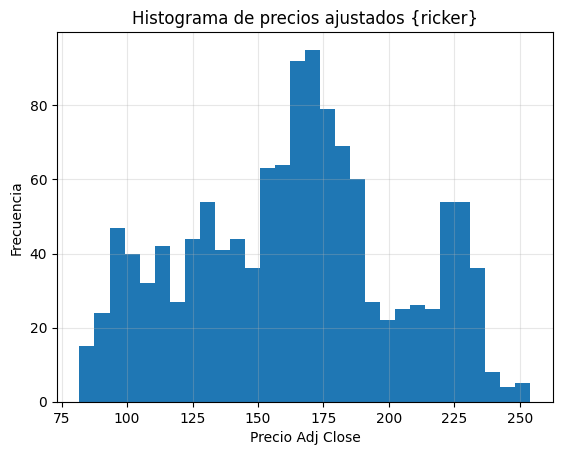

In [19]:
ticker = "AMZN"
bins = 30
prices = df.copy()

col = f"ADJ_CLOSE_{ticker}"

s = prices[col].dropna()

display(s.count())

plt.figure()
plt.hist(s.values, bins=bins)
plt.title("Histograma de precios ajustados {ricker}")
plt.ylabel("Frecuencia")
plt.xlabel("Precio Adj Close")
plt.grid(True, alpha=0.3)
plt.show()

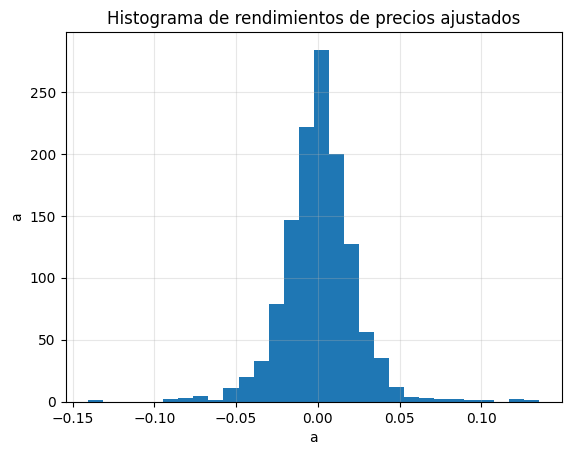

In [20]:
# Hacer histograma de rendimientos

# Reparto de utilidades. Puede o no existir un reparto de dividendos.

prices_2 = df.copy()

s = prices_2[col].dropna()
rendimientos = [(s[x]-s[x-1])/s[x-1] if x > 0 else 0 for x in range(0,s.count())]
# rendimientos = s[1:].values/s[:,-1].values - 1

# s[1:]/s[:,-1] - 1

# rendimientos = s.pct_change()     # Funcion que hace lo anterior

plt.figure()
plt.hist(rendimientos, bins=bins, )
plt.title("Histograma de rendimientos de precios ajustados")
plt.ylabel("a")
plt.xlabel("a")
plt.grid(True, alpha=0.3)
plt.show()


## Heatmap



In [21]:
prices_2 = df.copy()
price_cols = [col for col in prices_2.columns if col.startswith("ADJ")]

# Tarea: Obtener el heatmap  de correlacion de rendimientos

### Boxplot

In [22]:
ticker = "AAPL"
prices = df.copy()

col = f"ADJ_CLOSE_{}"

SyntaxError: f-string: valid expression required before '}' (1417327734.py, line 4)

### Serie de Tiempo

De los pocos usos que el profe conoce, este es uno de ellos para los index. En este tipo de graficos, setear la fecha como index.

Para que es normalize? - 